# 전력수요 EDA

학습 구간을 중심으로 분석합니다. 전체 기간 그래프는 분할 설명용입니다. 결측치 처리의 가정과 한계는 REPORT.md를 함께 읽어주세요.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    raise RuntimeError('프로젝트 폴더에서 노트북을 실행하세요.')
data = pd.read_csv(ROOT / 'data/processed/hourly_data.csv', parse_dates=['datetime']).set_index('datetime')
train = data.iloc[:6132]
print('전체:', len(data), '학습:', len(train))

전체: 8760 학습: 6132


## 원본 결측치와 대체 규칙

In [2]:
table = pd.read_csv(ROOT / 'results/missing_audit.csv')
print(table.to_string(index=False))

city              variable  observed_missing  absent_rows  total_missing                                                       rule
  광주         temperature_c                 0            1              1                                          forward fill only
  광주           rainfall_mm              7709            1           7710 observed-row blank: assumed zero; absent row: forward fill
  광주         wind_speed_ms                 9            1             10                                          forward fill only
  광주          humidity_pct                 0            1              1                                          forward fill only
  광주           sunshine_hr              3998            1           3999 observed-row blank: assumed zero; absent row: forward fill
  광주 solar_radiation_mj_m2              3998            1           3999 observed-row blank: assumed zero; absent row: forward fill
  대구         temperature_c                 0            0              0    

## 시간대별 수요

In [3]:
table = pd.read_csv(ROOT / 'results/eda_hourly.csv')
print(table.to_string(index=False))

 datetime         mean          std
        0 65511.600000  5929.246898
        1 61623.929688  5451.672424
        2 59178.968750  5156.860167
        3 57687.980469  4925.971454
        4 56901.648438  4753.745099
        5 56998.808594  4691.869500
        6 58110.371094  4926.356984
        7 60551.933594  5853.863749
        8 63718.156250  7967.868090
        9 66780.734375 10731.795467
       10 67498.796875 11960.857266
       11 66970.738281 12275.774068
       12 65350.632812 12299.668358
       13 63262.572549 11962.181629
       14 65405.090196 12529.185706
       15 66817.435294 12549.160193
       16 68346.541176 12226.958933
       17 70736.756863 11861.294432
       18 72320.580392 10998.264513
       19 73578.258824 10023.829321
       20 73579.333333  9335.428632
       21 71831.635294  8485.663900
       22 69263.529412  7455.933108
       23 67670.466667  6557.969288


## 요일별 수요

In [4]:
table = pd.read_csv(ROOT / 'results/eda_weekday.csv')
print(table.to_string(index=False))

 datetime         mean          std
        0 66307.799769 11515.051983
        1 68468.895833 10582.232076
        2 67982.058625 10341.044842
        3 68325.477477  9922.277825
        4 67668.896396  9821.945347
        5 61443.767389  7445.531570
        6 57427.825231  8658.811705


## 이상치 후보: 자동 삭제하지 않음

In [5]:
table = pd.read_csv(ROOT / 'results/eda_outlier_candidates.csv')
print(table.to_string(index=False))

           datetime  power_demand_mwh
2025-07-08 17:00:00           94968.0
2025-07-08 18:00:00           95675.0
2025-07-08 19:00:00           94703.0
2025-08-21 19:00:00           94599.0
2025-08-25 17:00:00           95142.0
2025-08-25 18:00:00           95951.0
2025-08-25 19:00:00           95731.0
2025-08-25 20:00:00           94765.0


## 전체 범위와 분할

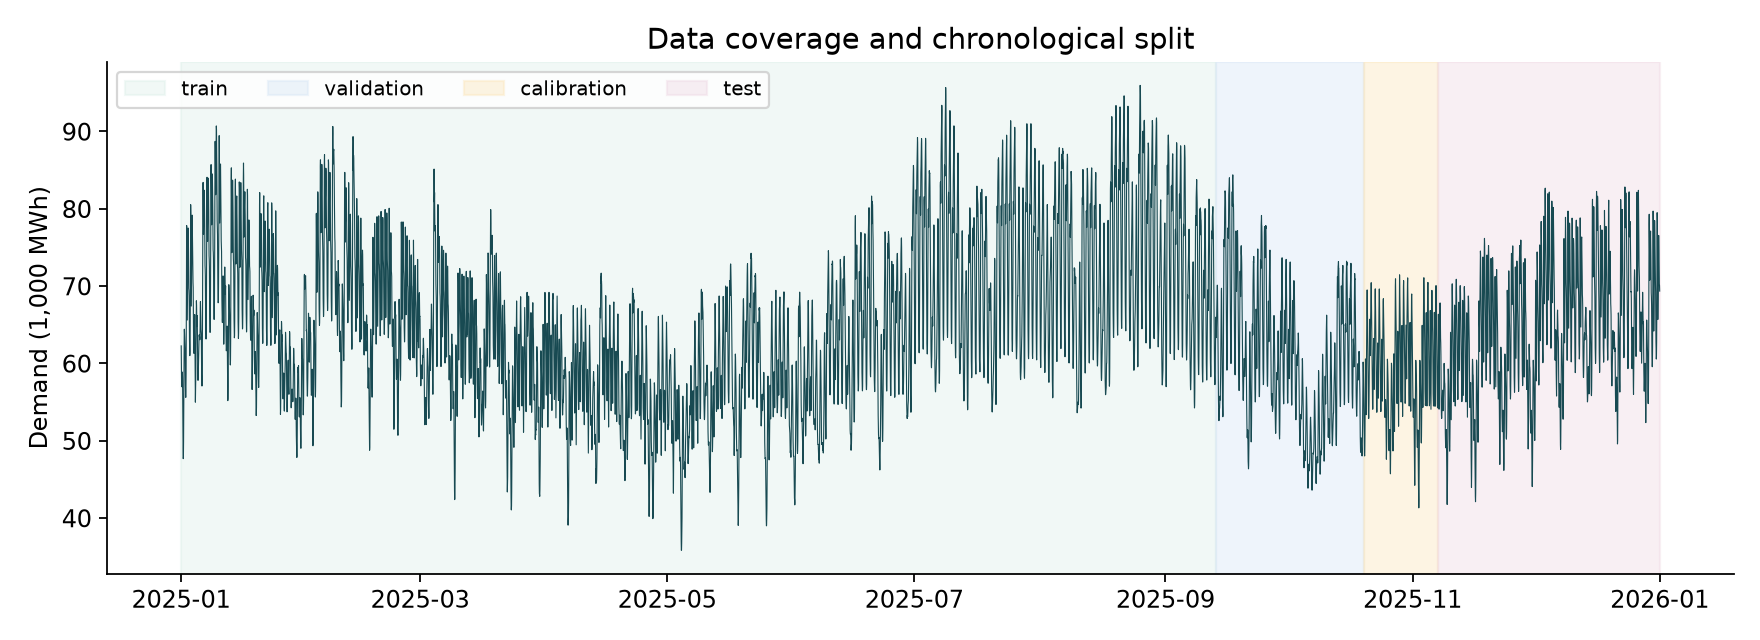

In [6]:
display(Image(filename=str(ROOT / 'figures/01_coverage.png')))

## 학습 구간 시간대·요일 패턴

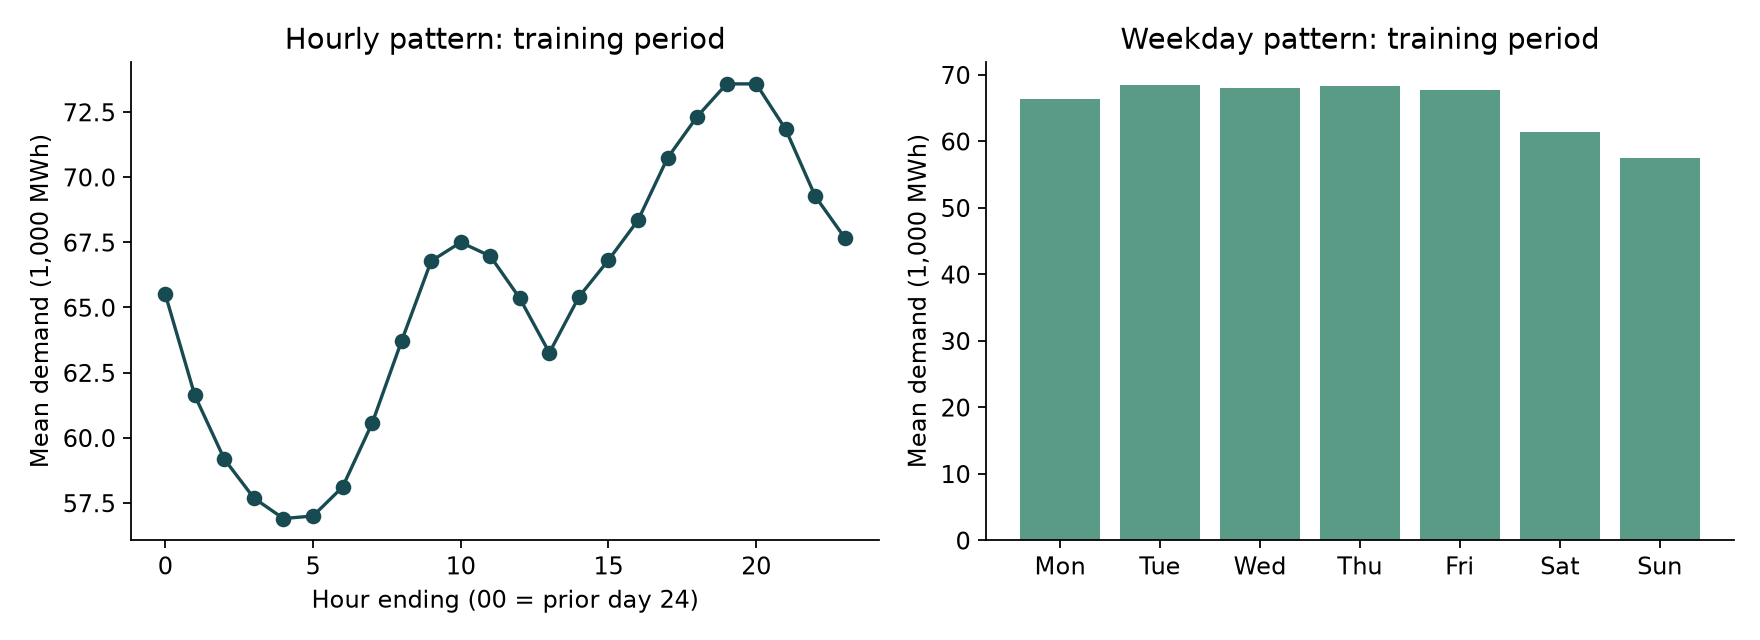

In [7]:
display(Image(filename=str(ROOT / 'figures/02_patterns.png')))

## 기온과 수요: 인과관계가 아닌 탐색

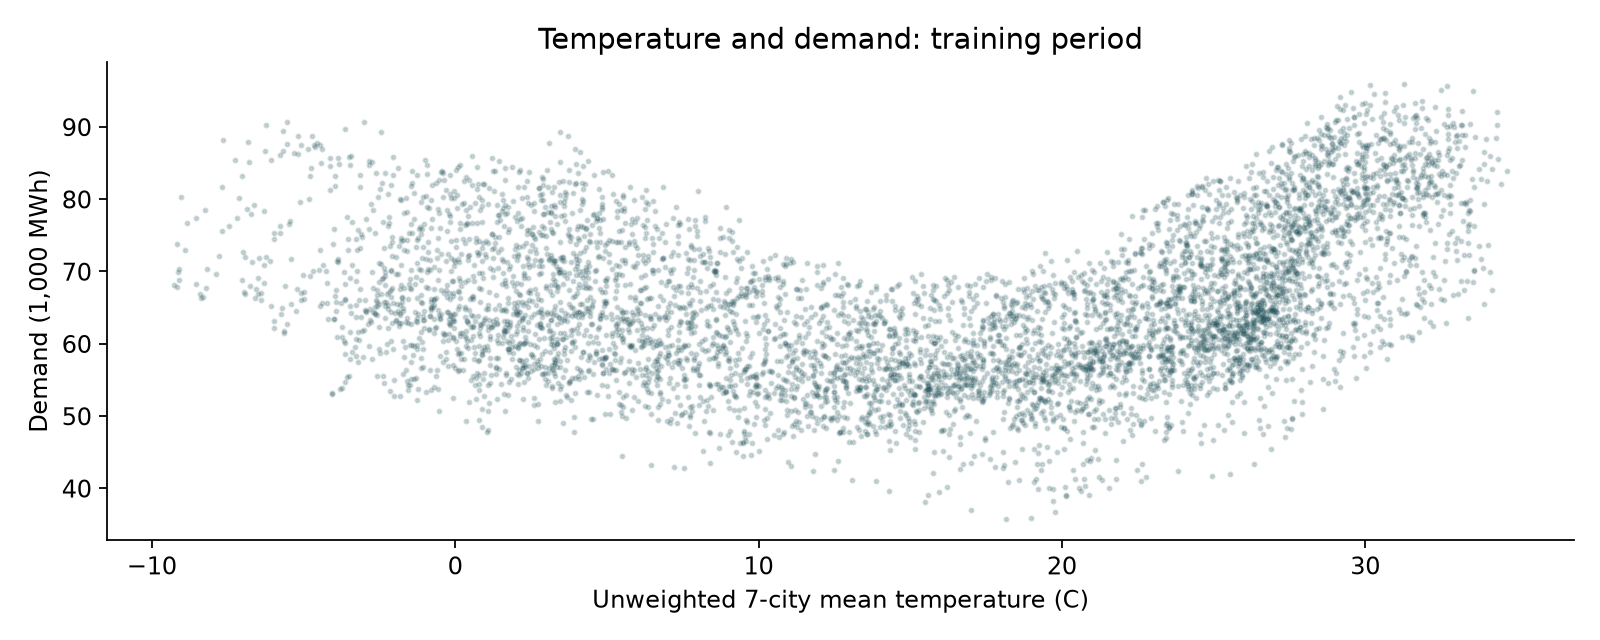

In [8]:
display(Image(filename=str(ROOT / 'figures/03_temperature.png')))

## 과거 수요와의 자기상관

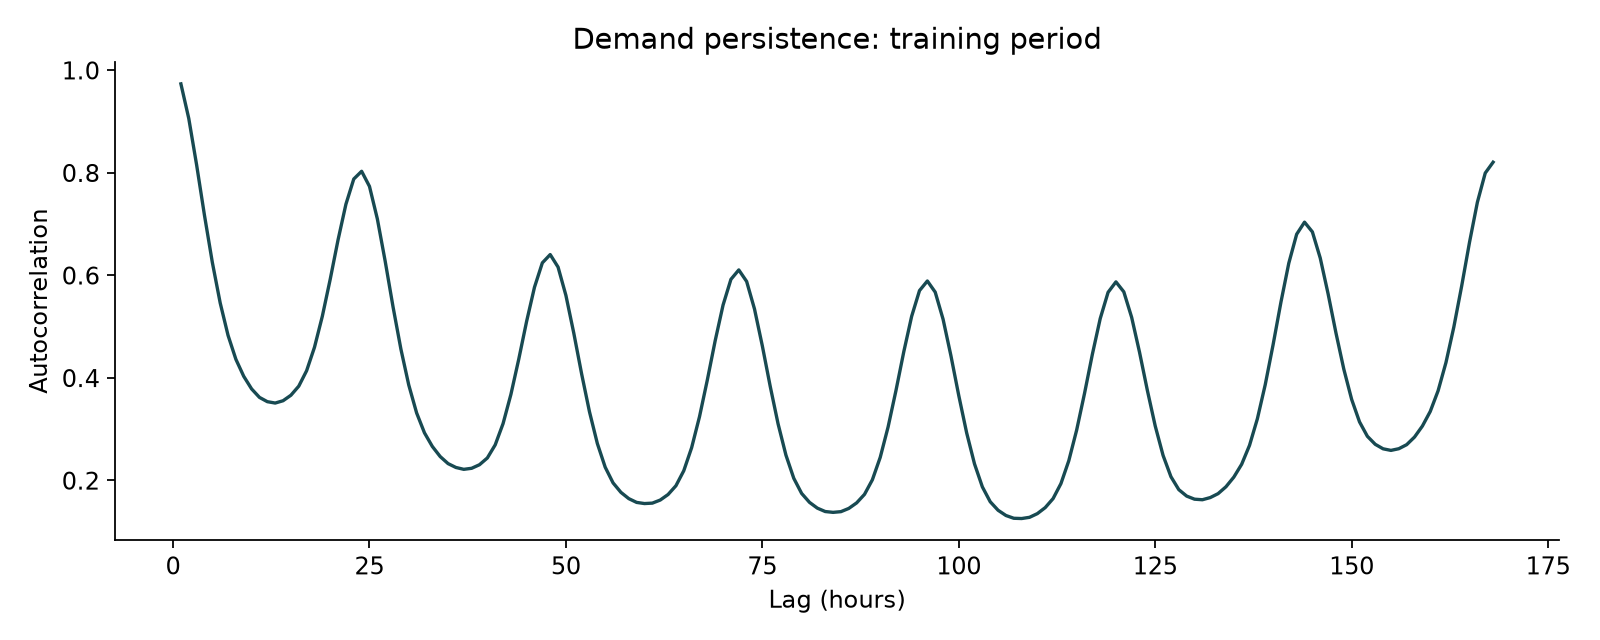

In [9]:
display(Image(filename=str(ROOT / 'figures/04_autocorrelation.png')))

## 해석

1시간 자기상관은 0.973으로 높습니다. 일·주 단위 기준선도 함께 비교합니다. 기온 단순 상관만으로 날씨의 영향 유무를 판단하지 않습니다. 결측치 0 대체는 명시적 가정이며 QC 정보로 후속 검증해야 합니다. EDA의 최대·최소 시간은 학습 구간 평균입니다.